# NYC HVFHV — Feature Engineering & Predictive Modeling

Builds an hourly demand forecasting model for the **Times Square pickup zone** to help FHVHV operators anticipate ride requests and inform driver pre-positioning. The analysis compares a **SARIMA model** against a naive **same-hour-last-week baseline** to determine whether a time-series model provides meaningful improvement.

**Input:** `fhvhv_clean_2026` + December 2025 raw data

**Output:** Engineered modeling dataset, SARIMA forecast, naive baseline, and forecast evaluation.

## Modeling Steps

- Apply the same cleaning logic to December 2025 data
- Combine December 2025 cleaned data with `fhvhv_clean_2026` to create `fhvhv_modeling_base`
- Build the zero-filled hourly Times Square demand series
- Establish a naive **same-hour-last-week** forecasting baseline
- Fit and diagnose a **SARIMA** model for Times Square
- Evaluate SARIMA against the naive baseline using a chronological holdout
- Analyze forecast errors and identify periods where the model performs well or poorly

In [1]:
from nyc_fhvhv.cleaning import clean_fhvhv
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox

con = duckdb.connect("../data/nyc_fhvhv_2026.duckdb")

con.sql("""
CREATE OR REPLACE TABLE fhvhv_raw_2025 AS
SELECT DISTINCT * 
FROM read_parquet('../data/raw/fhvhv_tripdata_2025-12.parquet')
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [2]:
# Apply cleaning function to the raw data and store the cleaned data in a new table
clean_fhvhv(
    con,
    raw_table="fhvhv_raw_2025",
    clean_table="fhvhv_clean_2025"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

'fhvhv_clean_2025'

In [3]:
con.sql("""
SHOW TABLES
""")

┌───────────────────────┐
│         name          │
│        varchar        │
├───────────────────────┤
│ fhvhv_clean_2025      │
│ fhvhv_clean_2026      │
│ fhvhv_modeling_base   │
│ fhvhv_raw_2025        │
│ fhvhv_raw_2026        │
│ times_square_baseline │
│ times_square_hourly   │
│ times_square_test     │
│ times_square_train    │
│ zone_lookup           │
└───────────────────────┘
         10 rows       

In [4]:
con.sql("""
SELECT * 
FROM fhvhv_clean_2025 
LIMIT 5
""").df()

,provider_name,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,pickup_borough,pickup_zone,...,congestion_surcharge,airport_fee,tips,driver_pay,cbd_congestion_fee,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,Uber,B03404,B03404,2025-12-18 06:05:17,2025-12-18 06:12:22,2025-12-18 06:12:22,2025-12-18 06:46:49,130,Queens,Jamaica,...,0.00,2.5,0.0,29.60,0.0,False,False,False,False,False
1,Uber,B03404,B03404,2025-12-18 06:49:49,2025-12-18 06:54:18,2025-12-18 06:54:51,2025-12-18 07:12:46,88,Manhattan,Financial District South,...,2.75,0.0,0.0,21.87,1.5,False,False,False,False,False
2,Uber,B03404,B03404,2025-12-18 06:03:20,2025-12-18 06:06:57,2025-12-18 06:07:19,2025-12-18 06:15:19,55,Brooklyn,Coney Island,...,0.00,0.0,0.0,7.84,0.0,False,False,False,False,True
3,Uber,B03404,B03404,2025-12-18 06:47:11,2025-12-18 06:55:42,2025-12-18 06:57:42,2025-12-18 07:11:17,257,Brooklyn,Windsor Terrace,...,0.00,0.0,0.0,11.21,0.0,False,False,False,False,False
4,Uber,B03404,B03404,2025-12-18 06:06:09,2025-12-18 06:08:09,2025-12-18 06:09:18,2025-12-18 06:21:39,170,Manhattan,Murray Hill,...,2.75,0.0,0.0,10.97,1.5,False,False,False,False,False


In [5]:
# Combine dataset from 2025 and 2026 into a single table for modeling
con.sql("""
CREATE OR REPLACE TABLE fhvhv_modeling_base AS
SELECT * FROM fhvhv_clean_2025
UNION ALL
SELECT * FROM fhvhv_clean_2026
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [6]:
con.sql("""
SELECT *
FROM fhvhv_modeling_base
LIMIT 5
""").df()

,provider_name,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,pickup_borough,pickup_zone,...,congestion_surcharge,airport_fee,tips,driver_pay,cbd_congestion_fee,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,Uber,B03404,B03404,2025-12-18 06:05:17,2025-12-18 06:12:22,2025-12-18 06:12:22,2025-12-18 06:46:49,130,Queens,Jamaica,...,0.00,2.5,0.0,29.60,0.0,False,False,False,False,False
1,Uber,B03404,B03404,2025-12-18 06:49:49,2025-12-18 06:54:18,2025-12-18 06:54:51,2025-12-18 07:12:46,88,Manhattan,Financial District South,...,2.75,0.0,0.0,21.87,1.5,False,False,False,False,False
2,Uber,B03404,B03404,2025-12-18 06:03:20,2025-12-18 06:06:57,2025-12-18 06:07:19,2025-12-18 06:15:19,55,Brooklyn,Coney Island,...,0.00,0.0,0.0,7.84,0.0,False,False,False,False,True
3,Uber,B03404,B03404,2025-12-18 06:47:11,2025-12-18 06:55:42,2025-12-18 06:57:42,2025-12-18 07:11:17,257,Brooklyn,Windsor Terrace,...,0.00,0.0,0.0,11.21,0.0,False,False,False,False,False
4,Uber,B03404,B03404,2025-12-18 06:06:09,2025-12-18 06:08:09,2025-12-18 06:09:18,2025-12-18 06:21:39,170,Manhattan,Murray Hill,...,2.75,0.0,0.0,10.97,1.5,False,False,False,False,False


In [7]:
con.sql("""
SELECT 
    COUNT(*) AS total_trips,
FROM fhvhv_modeling_base
WHERE pickup_zone LIKE 'Times Sq%'
""").df()

,total_trips
0,1340437


In [8]:
con.sql("""
SELECT
    COUNT(*) AS total_trips
FROM fhvhv_modeling_base
""").df()

,total_trips
0,125588563


In [9]:
# Create the zero-filled hourly time series 
con.sql("""
CREATE OR REPLACE TABLE times_square_hourly AS
-- A complete hourly timeline spanning Dec-Jan 2026
WITH hours AS (
    SELECT 
        unnest(generate_series(
            (SELECT min(date_trunc('hour', request_datetime)) FROM fhvhv_modeling_base),
            (SELECT max(date_trunc('hour', request_datetime)) FROM fhvhv_modeling_base),
            INTERVAL 1 HOUR
        )) AS hour_bucket
),

-- Real hourly counts of requests in Times Square
actual AS (
    SELECT 
        date_trunc('hour', request_datetime) AS hour_bucket,
        count(*) AS request_count
    FROM fhvhv_modeling_base
    WHERE pickup_zone LIKE 'Times Sq%'
    GROUP BY 1
)

SELECT 
    h.hour_bucket,
    COALESCE(a.request_count, 0) AS request_count  -- Fill in missing hours with 0 (SARIMA requires a complete time series)
FROM hours h
LEFT JOIN actual a 
ON h.hour_bucket = a.hour_bucket
ORDER BY h.hour_bucket;
""")

In [10]:
con.sql("""
SELECT 
    count(*) AS total_hours,
    min(hour_bucket) AS min_hour,
    max(hour_bucket) AS max_hour,
    SUM(CASE WHEN request_count = 0 THEN 1 ELSE 0 END) AS zero_count
FROM times_square_hourly;
""").df()

,total_hours,min_hour,max_hour,zero_count
0,4376,2025-11-30 16:00:00,2026-05-31 23:00:00,9.0


In [11]:
# Calculate the total number of hours in the time series for verification
pd.date_range(
    "2025-11-30 16:00",
    "2026-05-31 23:00",
    freq="h"
).size

4376

In [12]:
# Train-test split for modeling
con.sql("""
CREATE OR REPLACE TABLE times_square_train AS
SELECT *
FROM times_square_hourly
WHERE hour_bucket < '2026-05-01 00:00:00';

CREATE OR REPLACE TABLE times_square_test AS
SELECT *
FROM times_square_hourly
WHERE hour_bucket >= '2026-05-01 00:00:00';
""")

In [13]:
con.sql("""
SELECT 
    (SELECT count(*) FROM times_square_train) AS train_hours,
    (SELECT count(*) FROM times_square_test) AS test_hours
""").df()

,train_hours,test_hours
0,3632,744


In [14]:
pd.date_range(
    "2025-11-30 16:00:00",
    "2026-05-01 00:00:00",
    freq="h"
).size

3633

In [15]:
pd.date_range(
    "2026-05-01 00:00:00",
    "2026-05-31 23:00:00",
    freq="h"
).size

744

In [16]:
# Create the same-hour-last-week baseline for comparison
con.sql("""
CREATE OR REPLACE TABLE times_square_baseline AS
WITH last_week AS (
    SELECT
        hour_bucket,
        request_count,
        LAG(request_count, 168) OVER (ORDER BY hour_bucket) AS last_week_request_count
    FROM times_square_hourly
)

SELECT
    hour_bucket,
    request_count,
    last_week_request_count
FROM last_week
WHERE hour_bucket >= '2026-05-01 00:00:00';  -- Filter to only include the test period for evaluation
""")

In [17]:
# ADF test for stationarity
# Reason: Determine whether a time series is stationary or not. 
# If the data is not stationary, it may need to be transformed to achieve stationarity.
train_series = con.sql("SELECT hour_bucket, request_count FROM times_square_train ORDER BY hour_bucket").df()
train_series = train_series.set_index('hour_bucket')['request_count'].asfreq('h')

result = adfuller(train_series)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

if result[1] > 0.05:
    print("The time series is not stationary. Differencing (d=1) may be needed.")
else:
    print("The time series is stationary. No differencing (d=0) is needed.")

ADF Statistic: -7.0443
p-value: 0.0000
The time series is stationary. No differencing (d=0) is needed.


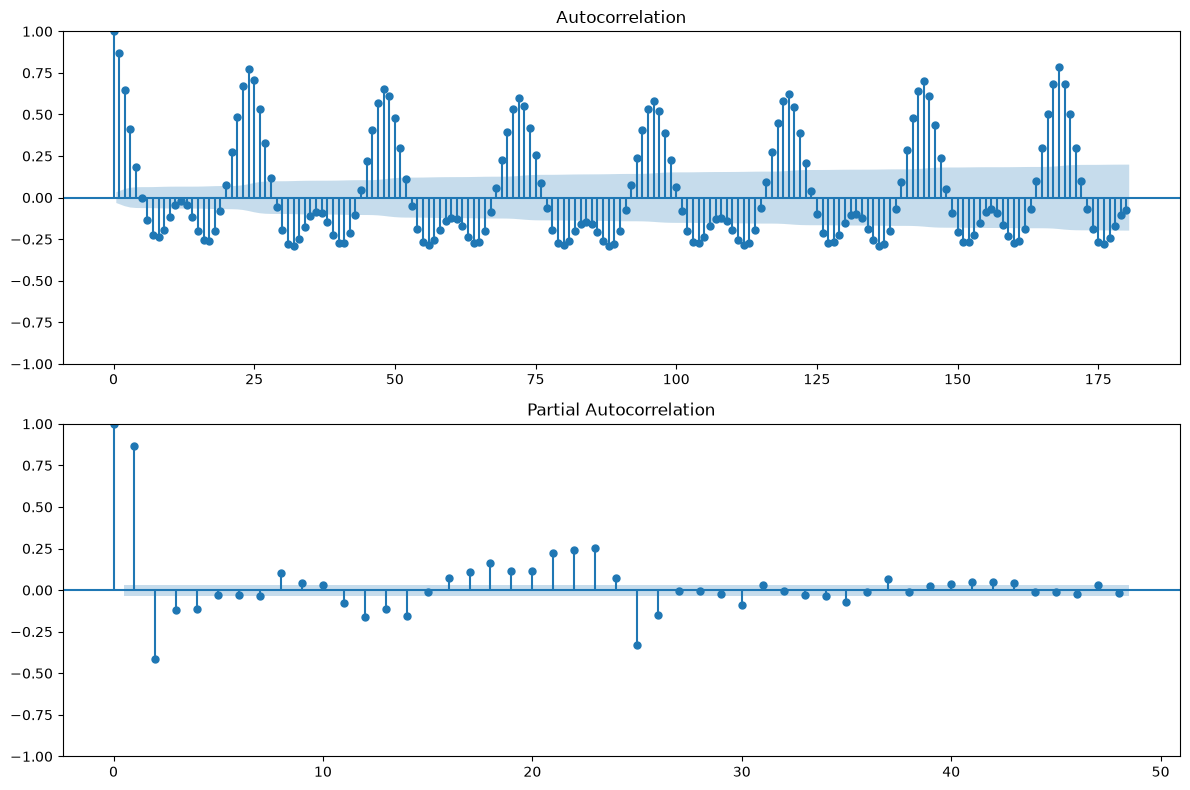

In [18]:
# ACF and PACF plots for determining AR and MA terms
# Reason: ACF and PACF plots help identify the order of the AR (AutoRegressive) and MA (Moving Average) components in the SARIMA model. 
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train_series, lags=180, ax=axes[0])
plot_pacf(train_series, lags=48, ax=axes[1])
plt.tight_layout()
plt.show()

### ACF / PACF Summary

**ACF**
- Strong, repeating spikes at **24, 48, 72, ..., 168** lags.
- This confirms a **24-hour (daily) seasonality**: `m = 24`.
- Size of spikes are consistent: suggests the weekly pattern may mostly come from the repeating **hour-of-day pattern**.

**PACF**
- Large spikes at **lag 1** and **lag 2**.

In [19]:
# Use auto_arima to find the best SARIMA model parameters
# Reason: auto_arima automates the process of identifying the best parameters for the SARIMA model based on the training data.
model = pm.auto_arima(
    train_series,
    start_p=2, max_p=2,
    d=0, max_d=0,
    start_q=0, max_q=3,
    seasonal=True,
    m=24,
    start_P=0, max_P=2,
    D=None, max_D=1,
    start_Q=0, max_Q=2,
    trace=True,
    stepwise=True,
    information_criterion='aic'
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,0)(0,0,0)[24] intercept   : AIC=41989.782, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=47743.881, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=40698.893, Time=3.71 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=43141.989, Time=2.41 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=52859.413, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[24] intercept   : AIC=42668.330, Time=0.04 sec
 ARIMA(1,0,0)(2,0,0)[24] intercept   : AIC=40624.043, Time=12.14 sec
 ARIMA(1,0,0)(2,0,1)[24] intercept   : AIC=inf, Time=15.96 sec
 ARIMA(1,0,0)(1,0,1)[24] intercept   : AIC=inf, Time=5.62 sec
 ARIMA(0,0,0)(2,0,0)[24] intercept   : AIC=inf, Time=8.84 sec
 ARIMA(2,0,0)(2,0,0)[24] intercept   : AIC=40613.309, Time=12.53 sec
 ARIMA(2,0,0)(1,0,0)[24] intercept   : AIC=40692.363, Time=4.64 sec
 ARIMA(2,0,0)(2,0,1)[24] intercept   : AIC=inf, Time=16.74 sec
 ARIMA(2,0,0)(1,0,1)[24] intercept   : AIC=inf, Time=5.79 sec
 ARIMA(2,0,1)(2,0,0)[24] interc

In [20]:
order = model.order
seasonal_order = model.seasonal_order

sarima_model = SARIMAX(
    train_series,
    order=order,
    seasonal_order=seasonal_order,
    trend='c'  # 'c' = include intercept/constant
)

sarima_fit = sarima_model.fit(disp=True)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      request_count   No. Observations:                 3632
Model:             SARIMAX(2, 0, 0)x(2, 0, 0, 24)   Log Likelihood              -20300.655
Date:                            Mon, 10 Aug 2026   AIC                          40613.309
Time:                                    18:20:48   BIC                          40650.495
Sample:                                11-30-2025   HQIC                         40626.556
                                     - 04-30-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     19.2734      1.952      9.876      0.000      15.448      23.098
ar.L1          0.8570      0.011   

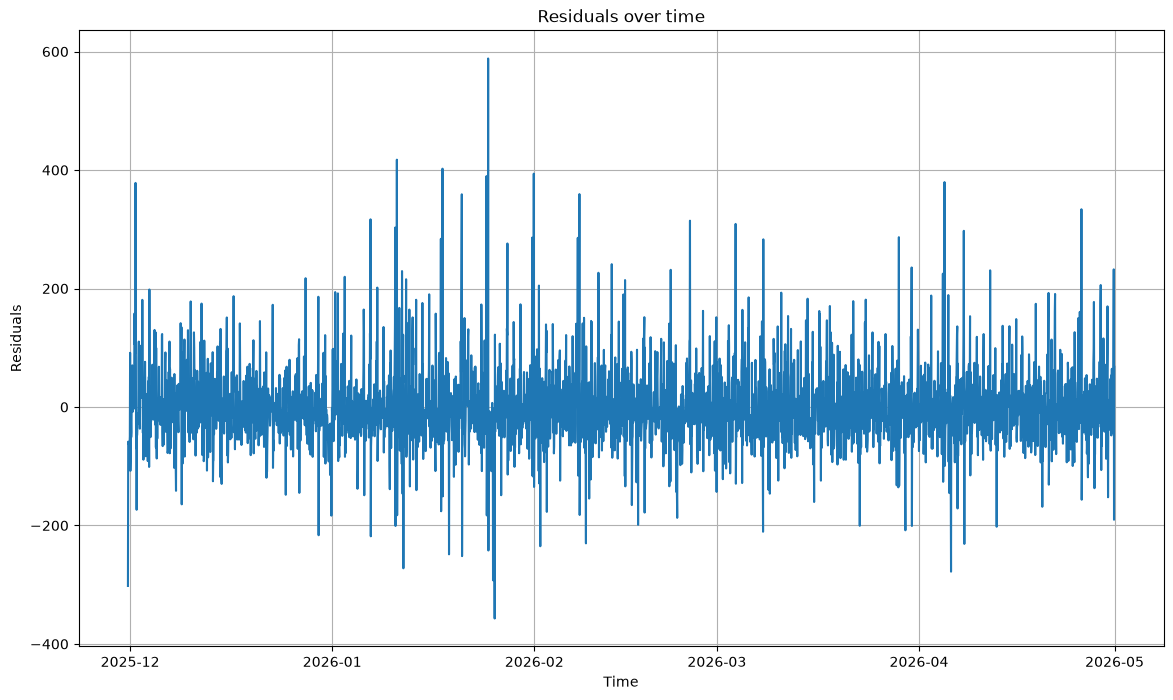

In [21]:
residuals = sarima_fit.resid

plt.figure(figsize=(14, 8))

# Plot residuals over time
plt.plot(residuals)
plt.title("Residuals over time")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()

<Figure size 1400x800 with 0 Axes>

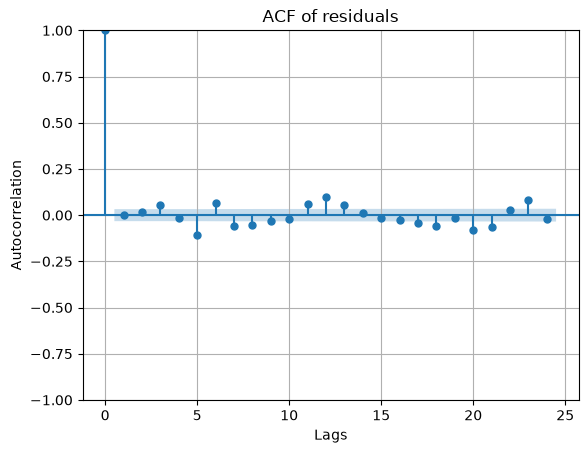

In [22]:
# Plot ACF of residuals to check for autocorrelation
plt.figure(figsize=(14, 8))
plot_acf(residuals, lags=24)
plt.title("ACF of residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

In [23]:
# Ljung-Box test
# Reason: The Ljung-Box test checks whether the residuals are independently distributed (i.e., no autocorrelation).
ljung_box_results = acorr_ljungbox(residuals, lags=[24], return_df=True)
print(ljung_box_results)

       lb_stat     lb_pvalue
24  251.340447  8.952436e-40


In [24]:
test_series = con.sql("SELECT hour_bucket, request_count FROM times_square_test ORDER BY hour_bucket").df()
test_series = test_series.set_index('hour_bucket')['request_count'].asfreq('h')

baseline = con.sql("SELECT last_week_request_count FROM times_square_baseline ORDER BY hour_bucket").df()['last_week_request_count']

In [25]:
# Rolling forecast
# Reason: A rolling forecast allows the model to update its predictions based on new observations, 
# which can improve accuracy over time.
history_model = sarima_fit  # already fit through April 30

rolling_forecasts = []

for start in range(0, len(test_series), 24):
    # forecast the next 24 hours given everything seen so far
    step_forecast = history_model.get_forecast(steps=24).predicted_mean
    rolling_forecasts.extend(step_forecast.values)

    # reveal the real values for those 24 hours, update state
    new_obs = test_series.iloc[start:start+24]
    history_model = history_model.append(new_obs, refit=False)

sarima_forecast_rolling = pd.Series(rolling_forecasts, index=test_series.index)

In [26]:
results = pd.DataFrame({'request_count': test_series})
results['sarima_forecast'] = sarima_forecast_rolling.values
results['baseline'] = baseline.values

In [27]:
# Calculate MAE for the rolling SARIMA forecast and compare with baseline
sarima_mae = mean_absolute_error(results['request_count'], results['sarima_forecast'])
baseline_mae = mean_absolute_error(results['request_count'], results['baseline'])

print(f"SARIMA (rolling 24h) MAE: {sarima_mae:.2f}")
print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Improvement over baseline: {((baseline_mae - sarima_mae) / baseline_mae) * 100:.2f}%")

SARIMA (rolling 24h) MAE: 72.77
Baseline MAE: 56.87
Improvement over baseline: -27.95%


In [28]:
# Calculate MAE by day of the week for both SARIMA and baseline
results['day_of_week'] = results.index.day_name()
error_by_day = results.groupby('day_of_week').apply(
    lambda d: pd.Series({
        'sarima_mae': mean_absolute_error(d['request_count'], d['sarima_forecast']),
        'baseline_mae': mean_absolute_error(d['request_count'], d['baseline'])
    })
)
print(error_by_day)

             sarima_mae  baseline_mae
day_of_week                          
Friday        58.759812     32.700000
Monday        81.966059     50.979167
Saturday      72.850828     71.141667
Sunday        63.270551     66.891667
Thursday      56.337540     53.614583
Tuesday      100.603110     59.968750
Wednesday     81.433507     62.781250


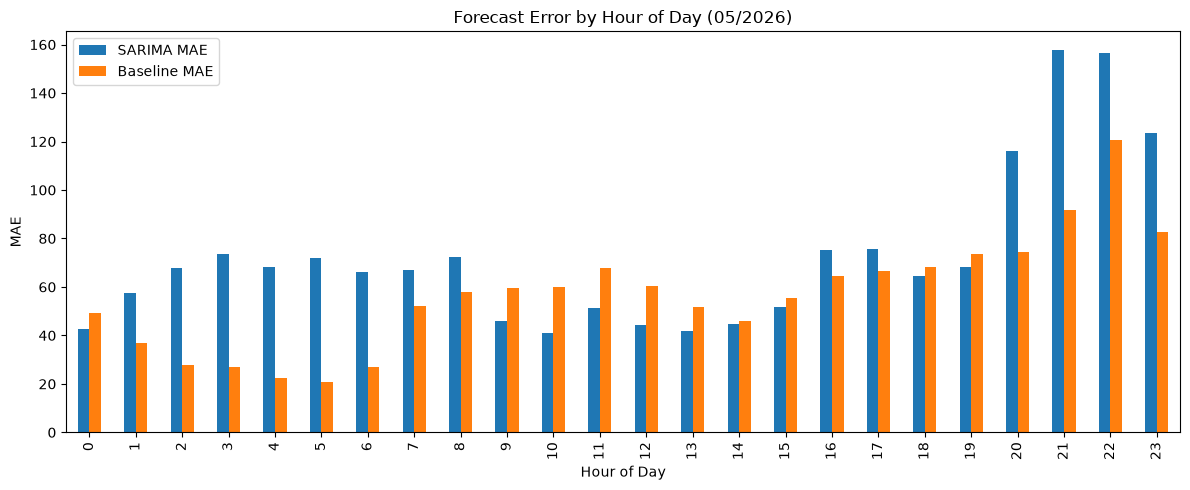

In [29]:
# Error by hour of the day for both SARIMA and baseline
results['hour'] = results.index.hour

hourly_mae = results.groupby('hour').apply(
    lambda x: pd.Series({
        'SARIMA MAE': mean_absolute_error(
            x['request_count'], x['sarima_forecast']
        ),
        'Baseline MAE': mean_absolute_error(
            x['request_count'], x['baseline']
        )
    })
)

hourly_mae.plot(kind='bar', figsize=(12, 5))

plt.xlabel('Hour of Day')
plt.ylabel('MAE')
plt.title('Forecast Error by Hour of Day (05/2026)')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

- Baseline MAE: 56.9
- SARIMA MAE: 72.8
- The baseline outperformed SARIMA for Times Square in May 2026.
- SARIMA performed better during some midday hours, but had higher errors during the evening, particularly 8-11 PM.
- By day of week, SARIMA had higher MAE than the baseline on 6 of 7 days, with the largest differences on Tuesday, Monday, and Wednesday.
- SARIMA only outperformed the baseline on Sunday.
- Results are limited to Times Square and May 2026.

In [30]:
con.close()